#importing the libraries

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

#### **load the data**

In [62]:
housing_data=pd.read_csv("/content/Housing.csv")
housing_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


###**check the columns name**

In [63]:
housing_data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

###**check the columns datatype and null values**

In [64]:
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


###**convert the categorical data into numeric data 0 or 1**

In [65]:
categorical_cols=['mainroad','guestroom', 'basement', 'hotwaterheating', 'airconditioning','prefarea']
for cols in categorical_cols:
  housing_data[cols]= housing_data[cols].map({'yes':1, 'no':0})

In [66]:
housing_data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,unfurnished
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,unfurnished
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,furnished


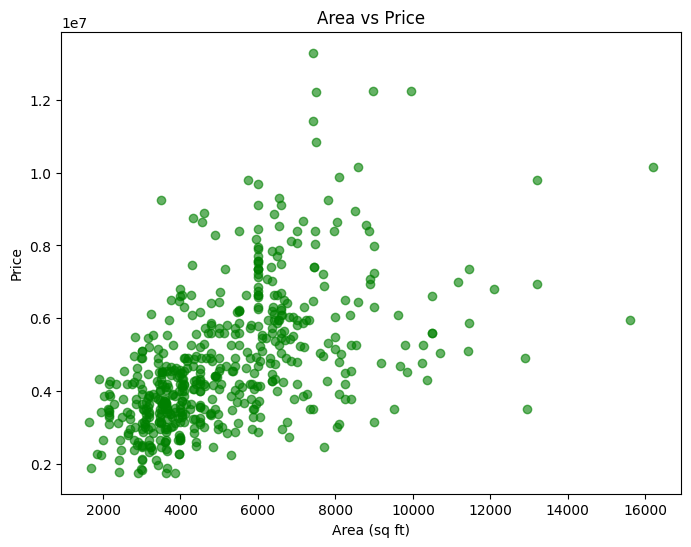

In [82]:
plt.figure(figsize=(8,6))
plt.scatter(housing_data['area'], housing_data['price'], color='green', alpha=0.6)
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

###**get cateforical column into dummies data**

In [67]:
housing_data=pd.get_dummies(housing_data, columns=['furnishingstatus'], drop_first=True)
bool_cols=housing_data.select_dtypes(include=bool).columns
housing_data[bool_cols]=housing_data[bool_cols].astype(int)


##**Now all data is in numeric form and ready for model training**

In [68]:
housing_data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [74]:
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    i

###**Assigning inpyt input and output variables**

In [69]:
X=housing_data.drop('price', axis=1)
Y=housing_data['price']

In [70]:
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [71]:
Y.head()

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000


##**split the data into training and testing data and model training**

In [72]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=2, random_state=42)
linera_model=LinearRegression()
train_model=linera_model.fit(x_train,y_train)
train_model

LinearRegression()

###**Evaluate the model**

In [73]:
from sklearn.metrics import r2_score, mean_squared_error
y_pred=train_model.predict(x_test)
print("R²:", r2_score(y_test, y_pred))
print('mean_squared_error',np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.5905770248997593
mean_squared_error 828620.8812342839


In [88]:
residual=y_test - y_pred
residual

,price
316,-1.578485e+06
77,-3.311985e+05
360,8.819449e+04
90,1.363307e+06
493,-7.968780e+05
...,...
15,4.867471e+06
357,-7.493108e+05
39,1.084598e+06
54,5.245983e+05


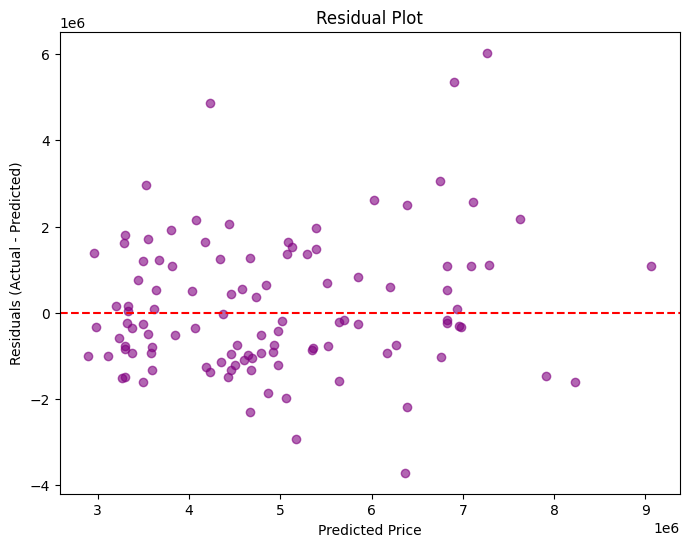

In [89]:
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residual, color='purple', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

##why model accuracy is low and error is high?

**Non-linear relationships** – House prices often don't increase linearly with features like area, bedrooms, or bathrooms. For example, an extra bedroom may add a lot of value in a small house but very little in an already-large one. Linear regression can't capture these diminishing/varying effects.

In [79]:
min_price=housing_data['price'].min()
min_price

1750000

In [78]:
max_price=housing_data['price'].max()
max_price

13300000

In [80]:
##high price difference range in price column which make non linear relationship
max_price - min_price

11550000

**Missing influential factors** – Price is heavily driven by factors not present in this dataset, such as exact location, neighborhood quality, build year, and market conditions. Without these, the model is working with incomplete information.

**Outliers** – A few unusually high or low-priced houses can disproportionately pull the regression line, increasing error for the majority of "normal" houses.


**High variance in price scale**  